# ML Regression from Scratch - Notebook 6: Logistic Regression & Classification

**Goal:** predict whether a student **passes** the capstone
(`CapstoneScore >= 50`) or **fails** (`< 50`), using **binary logistic
regression built from scratch** with NumPy - sigmoid, cross-entropy loss,
gradient descent, all of it.

Same five mapped features:
`Attendance`, `TotalHours`, `AssignmentsCompleted`, `GitHubScore`, `PeerReviewScore`.

We will:
1. Build the binary pass/fail label and check class balance
2. Implement `sigmoid`, `compute_logistic_cost`, `compute_logistic_gradients`,
   `logistic_gradient_descent`, `predict_proba`, `predict_class`
3. Train the model and check convergence
4. Look at basic classification results (confusion matrix, accuracy,
   precision, recall, F1)



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

## 1. Load data & build the binary label

`Pass = 1` if `CapstoneScore >= 50`, else `Fail = 0`. We use 50 rather than
a stricter cutoff (e.g. 75) specifically because it splits the class
roughly in the middle instead of leaving only a handful of positive
examples - a much more workable target for a from-scratch classifier on
a ~70-row dataset.

In [ ]:
df = pd.read_csv('zuu_crew_scores.csv')
df = df[df['CourseName'] == 'Foundations of ML'].reset_index(drop=True)

feature_cols = ['Attendance', 'TotalHours', 'AssignmentsCompleted', 'GitHubScore', 'PeerReviewScore']

df['Pass'] = (df['CapstoneScore'] >= 50).astype(int)

print(f"Rows: {len(df)}")
print(df['Pass'].value_counts().rename({0: 'Fail (0)', 1: 'Pass (1)'}))
print(f"Pass rate: {df['Pass'].mean():.1%}")

Rows: 72
Pass
Pass (1)    42
Fail (0)    30
Name: count, dtype: int64
Pass rate: 58.3%


With a 50-point cutoff the classes are reasonably balanced (roughly
3-to-2), so
a plain accuracy number is a much more trustworthy headline metric here
than it would be on a heavily skewed label - no majority-class trick can
score above ~58% for free. We'll still look at precision/recall/F1
alongside accuracy, since a balanced class count doesn't guarantee a
balanced *error* profile.

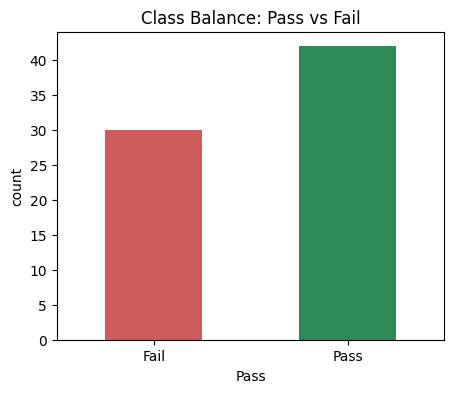

In [ ]:
plt.figure(figsize=(5, 4))
df['Pass'].value_counts().sort_index().plot(kind='bar', color=['indianred', 'seagreen'])
plt.xticks([0, 1], ['Fail', 'Pass'], rotation=0)
plt.ylabel('count')
plt.title('Class Balance: Pass vs Fail')
plt.show()

## 2. Train/test split & feature scaling

Same pattern as the linear regression notebooks: shuffle-split from
scratch, standardize using train statistics only. Because the classes
are close to balanced, a plain random 80/20 split is enough to land
examples of both classes in the test set.

In [ ]:
def train_test_split_scratch(X, Y, test_size=0.2, seed=42):
    m = len(Y)
    rng = np.random.RandomState(seed)
    shuffled_idx = rng.permutation(m)
    n_test = int(m * test_size)
    test_idx = shuffled_idx[:n_test]
    train_idx = shuffled_idx[n_test:]
    return X[train_idx], X[test_idx], Y[train_idx], Y[test_idx]


def standardize_features(X, mu=None, sigma=None):
    if mu is None or sigma is None:
        mu = X.mean(axis=0)
        sigma = X.std(axis=0)
    return (X - mu) / sigma, mu, sigma


def add_bias(X):
    return np.column_stack([np.ones(len(X)), X])


X = df[feature_cols].values.astype(float)
y = df['Pass'].values.astype(float)

X_train, X_test, y_train, y_test = train_test_split_scratch(X, y, test_size=0.2, seed=42)

X_train_scaled, mu, sigma = standardize_features(X_train)
X_test_scaled, _, _ = standardize_features(X_test, mu, sigma)

X_train_design = add_bias(X_train_scaled)
X_test_design = add_bias(X_test_scaled)

print(f"Train: {X_train_design.shape}, Test: {X_test_design.shape}")
print(f"Train pass rate: {y_train.mean():.1%},  Test pass rate: {y_test.mean():.1%}")

Train: (58, 6), Test: (14, 6)
Train pass rate: 60.3%,  Test pass rate: 50.0%


## 3. The maths, from absolute basics

**Sigmoid** squashes any real number into a probability between 0 and 1:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**Hypothesis** :- same linear combination as linear regression, but passed
through the sigmoid so the output is a *probability of the positive
class* (Pass):

$$h_\theta(\mathbf x) = \sigma(\boldsymbol\theta^\top \mathbf x) = \frac{1}{1+e^{-\boldsymbol\theta^\top \mathbf x}}$$

**Cost :- binary cross-entropy** (log loss), which heavily penalizes
confident-but-wrong predictions:

$$J(\boldsymbol\theta) = -\frac{1}{m}\sum_{i=1}^{m}\Big[y_i\log h_\theta(\mathbf x_i) + (1-y_i)\log(1-h_\theta(\mathbf x_i))\Big]$$

Only one of the two log terms is "active" for any given row: if $y_i=1$,
the second term vanishes and we only pay a penalty for a low predicted
probability; if $y_i=0$, the first term vanishes and we pay a penalty for
a high predicted probability.

**Gradient** :- remarkably, this comes out to *exactly the same form* as
linear regression's gradient, just with $h_\theta(\mathbf x)$ (a
sigmoid output) in place of a raw linear prediction:

$$\nabla J(\boldsymbol\theta) = \frac{1}{m}X^\top(h_\theta(X)-\mathbf y)$$

**Update rule** is identical to linear regression too:
$\boldsymbol\theta := \boldsymbol\theta - \alpha\nabla J(\boldsymbol\theta)$.

### 3.1 `sigmoid`

In [ ]:
def sigmoid(z):
    """
    Logistic sigmoid, applied elementwise. Clips z to avoid overflow in
    exp() for very large positive/negative inputs (the mathematical
    result is unaffected — sigmoid saturates at 0/1 either way).
    """
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))


# Sanity checks: sigmoid(0) = 0.5, and it saturates towards 0 / 1
print(f"sigmoid(0)   = {sigmoid(0):.4f}")
print(f"sigmoid(10)  = {sigmoid(10):.4f}")
print(f"sigmoid(-10) = {sigmoid(-10):.4f}")

sigmoid(0)   = 0.5000
sigmoid(10)  = 1.0000
sigmoid(-10) = 0.0000


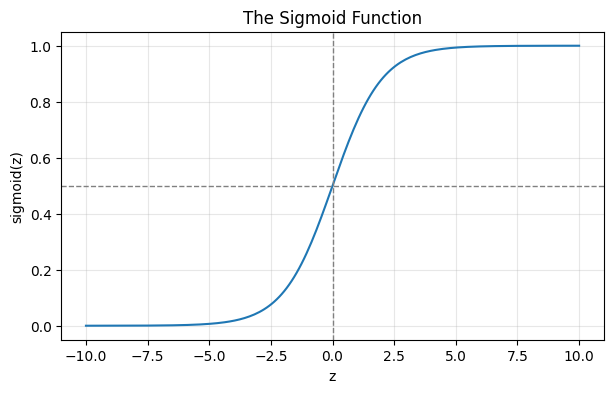

In [ ]:
z_vals = np.linspace(-10, 10, 200)
plt.figure(figsize=(7, 4))
plt.plot(z_vals, sigmoid(z_vals))
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('z')
plt.ylabel('sigmoid(z)')
plt.title('The Sigmoid Function')
plt.grid(alpha=0.3)
plt.show()

### 3.2 `compute_logistic_cost`

In [ ]:
def compute_logistic_cost(X_design, y, theta, eps=1e-15):
    """
    Binary cross-entropy cost.

    X_design : (m, n+1) design matrix (bias column included)
    y        : (m,) binary labels (0 or 1)
    theta    : (n+1,) parameters
    eps      : tiny constant to avoid log(0), which is -inf

    Returns a single float.
    """
    m = len(y)
    h = sigmoid(X_design.dot(theta))
    h = np.clip(h, eps, 1 - eps)   # keep log() well-defined
    cost = -(1 / m) * np.sum(y * np.log(h) + (1 - y) * np.log(1 - h))
    return cost


# Cost at theta = 0 should be close to -log(0.5) = 0.693 (pure guessing)
test_cost = compute_logistic_cost(X_train_design, y_train, theta=np.zeros(X_train_design.shape[1]))
print(f"Cost at theta=0 (should be close to ln(2) = 0.6931): {test_cost:.4f}")

Cost at theta=0 (should be close to ln(2) = 0.6931): 0.6931


### 3.3 `compute_logistic_gradients`

In [ ]:
def compute_logistic_gradients(X_design, y, theta):
    """Vectorised gradient of the cross-entropy cost w.r.t. every theta_j."""
    m = len(y)
    h = sigmoid(X_design.dot(theta))
    return (1 / m) * X_design.T.dot(h - y)


grad_test = compute_logistic_gradients(X_train_design, y_train, theta=np.zeros(X_train_design.shape[1]))
print(f"Gradient at theta=0: {grad_test.round(4)}")

Gradient at theta=0: [-0.1034 -0.0958 -0.4031 -0.0405 -0.1131 -0.0098]


### 3.4 `logistic_gradient_descent`

In [ ]:
def logistic_gradient_descent(X_design, y, learning_rate, n_iterations=3000, theta_init=None):
    """
    Batch gradient descent for logistic regression.

    Returns theta, cost_history (stops early only if the cost becomes
    non-finite, which is rare for logistic regression since sigmoid
    naturally bounds predictions).
    """
    n = X_design.shape[1]
    theta = np.zeros(n) if theta_init is None else theta_init
    cost_history = []

    for i in range(n_iterations):
        cost = compute_logistic_cost(X_design, y, theta)
        if not np.isfinite(cost):
            break
        cost_history.append(cost)
        theta = theta - learning_rate * compute_logistic_gradients(X_design, y, theta)

    return theta, cost_history

### 3.5 `predict_proba` and `predict_class`

In [ ]:
def predict_proba(X_design, theta):
    """Predicted probability of the positive class (Pass) for each row."""
    return sigmoid(X_design.dot(theta))


def predict_class(X_design, theta, threshold=0.5):
    """Threshold the predicted probabilities into hard 0/1 class labels."""
    return (predict_proba(X_design, theta) >= threshold).astype(int)

## 4. Train the model

In [ ]:
LEARNING_RATE = 0.5
N_ITERATIONS = 3000

theta, cost_history = logistic_gradient_descent(X_train_design, y_train, LEARNING_RATE, N_ITERATIONS)

print(f"Trained for {len(cost_history)} iterations")
print(f"Final training cost: {cost_history[-1]:.4f}")
print("Learned theta (bias, then one weight per standardized feature):")
for name, value in zip(['bias'] + feature_cols, theta):
    print(f"  {name:<22} {value:8.4f}")

Trained for 3000 iterations
Final training cost: 0.0655
Learned theta (bias, then one weight per standardized feature):
  bias                     3.7374
  Attendance               0.8837
  TotalHours              10.9937
  AssignmentsCompleted    -2.1394
  GitHubScore             -0.2471
  PeerReviewScore         -0.4034


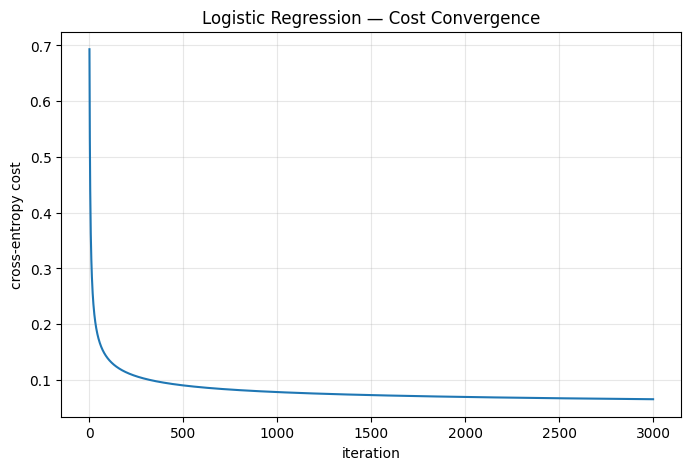

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(cost_history)
plt.xlabel("iteration")
plt.ylabel("cross-entropy cost")
plt.title("Logistic Regression — Cost Convergence")
plt.grid(alpha=0.3)
plt.show()

## 5. Classification results

A first look at how the model does with the standard 0.5 decision
threshold. (Precision/recall trade-offs at other thresholds, ROC/AUC, and
a deeper discussion of these numbers live in the comprehensive-metrics
notebook.)

In [ ]:
def confusion_matrix(y_true, y_pred):
    """
    Returns (TP, TN, FP, FN) counts.
    Positive class = 1 (Pass), negative class = 0 (Fail).
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp, tn, fp, fn


def accuracy_score(y_true, y_pred):
    tp, tn, fp, fn = confusion_matrix(y_true, y_pred)
    return (tp + tn) / (tp + tn + fp + fn)


def precision_score(y_true, y_pred):
    tp, tn, fp, fn = confusion_matrix(y_true, y_pred)
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0


def recall_score(y_true, y_pred):
    tp, tn, fp, fn = confusion_matrix(y_true, y_pred)
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0


def f1_score(y_true, y_pred):
    p, r = precision_score(y_true, y_pred), recall_score(y_true, y_pred)
    return 2 * p * r / (p + r) if (p + r) > 0 else 0.0

In [ ]:
y_pred_train = predict_class(X_train_design, theta, threshold=0.5)
y_pred_test = predict_class(X_test_design, theta, threshold=0.5)

for split_name, y_true, y_pred in [('train', y_train, y_pred_train), ('test', y_test, y_pred_test)]:
    tp, tn, fp, fn = confusion_matrix(y_true, y_pred)
    print(f"--- {split_name} (threshold = 0.5) ---")
    print(f"  Confusion matrix: TP={tp}  TN={tn}  FP={fp}  FN={fn}")
    print(f"  Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"  Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"  F1-score:  {f1_score(y_true, y_pred):.4f}")
    print()

--- train (threshold = 0.5) ---
  Confusion matrix: TP=34  TN=22  FP=1  FN=1
  Accuracy:  0.9655
  Precision: 0.9714
  Recall:    0.9714
  F1-score:  0.9714

--- test (threshold = 0.5) ---
  Confusion matrix: TP=6  TN=5  FP=2  FN=1
  Accuracy:  0.7857
  Precision: 0.7500
  Recall:    0.8571
  F1-score:  0.8000



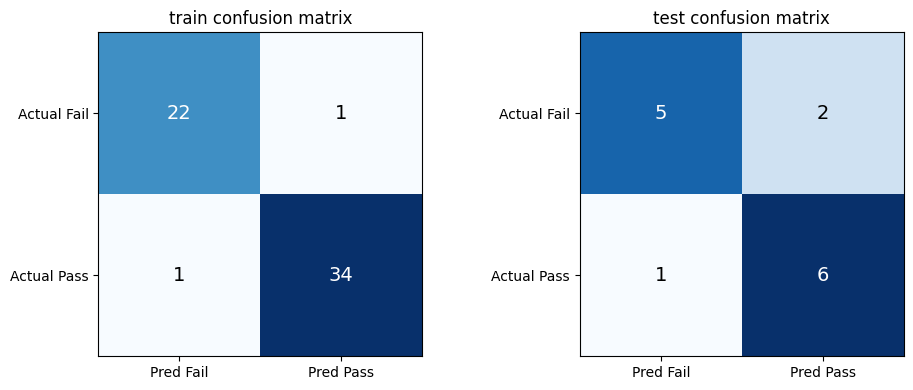

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, split_name, y_true, y_pred in [
    (axes[0], 'train', y_train, y_pred_train),
    (axes[1], 'test', y_test, y_pred_test),
]:
    tp, tn, fp, fn = confusion_matrix(y_true, y_pred)
    matrix = np.array([[tn, fp], [fn, tp]])
    im = ax.imshow(matrix, cmap='Blues')
    for (i, j), val in np.ndenumerate(matrix):
        ax.text(j, i, str(val), ha='center', va='center', fontsize=14,
                color='white' if val > matrix.max() / 2 else 'black')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Pred Fail', 'Pred Pass'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Actual Fail', 'Actual Pass'])
    ax.set_title(f"{split_name} confusion matrix")
plt.tight_layout()
plt.show()

Both classes are represented in the test set now (unlike a stricter
cutoff, which can easily push nearly every positive example into the
training fold on a small dataset), so precision and recall above are
telling us something real rather than being artifacts of an unlucky
split.

## 6. Interpreting the coefficients

Same idea as the linear regression notebooks: since every feature is
standardized, coefficient magnitude reflects how strongly a
one-standard-deviation change in that feature shifts the log-odds of
passing.

In [ ]:
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'standardized_weight': theta[1:],
}).sort_values('standardized_weight', key=abs, ascending=False)

coef_df

,feature,standardized_weight
1,TotalHours,10.993719
2,AssignmentsCompleted,-2.139439
0,Attendance,0.883679
4,PeerReviewScore,-0.403373
3,GitHubScore,-0.247123


## 7. Takeaways

- `sigmoid`, `compute_logistic_cost`, `compute_logistic_gradients`,
  `logistic_gradient_descent`, `predict_proba`, and `predict_class` are
  all implemented with plain NumPy, matching the function names required
  by the assignment.
- The gradient formula turned out identical in *shape* to linear
  regression's - only the hypothesis changed (sigmoid instead of a raw
  linear combination) - which is a nice reminder that gradient descent
  itself doesn't care about the model, only about being able to compute a
  cost and a gradient for it.